In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

### Handle Missing values

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].median)

In [6]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

### Feature Engineering

In [7]:
# Age
df["Age"] =  2026 - df["Year_Birth"]

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [9]:
# Joining days of customer

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_tenure_days"] = (reference_date - df["Dt_Customer"]).dt.days

In [10]:
# Spending

df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntGoldProds"] + df["MntSweetProducts"]

In [11]:
# Children

df["Total_children"] = df["Kidhome"] + df["Teenhome"]

In [12]:
# Education

df["Education"].value_counts()

# Undergraduate, Graduate, Postgraduate

df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate", "2n Cycle" : "Undergraduate",
    "Graduation" : "graduate",
    "Master" : "Postgraduate", "PhD" : "Postgraduate"
})

In [13]:
# Marital status

df["Marital_Status"].value_counts()

df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner", "Together" : "Partner", 
    "Single" : "Alone" , "Divorced" : "Alone",
    "Widow" : "Alone", "Absurd" : "Alone", "YOLO" : "Alone"
})

In [14]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

### Drop Columns

In [15]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer", "MntWines", "MntFruits",
        "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

df_cleaned = df.drop(columns=cols)

In [16]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Total_children,Living_With
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [17]:
df_cleaned["Income"] = pd.to_numeric(df_cleaned["Income"], errors="coerce")


### Outliers

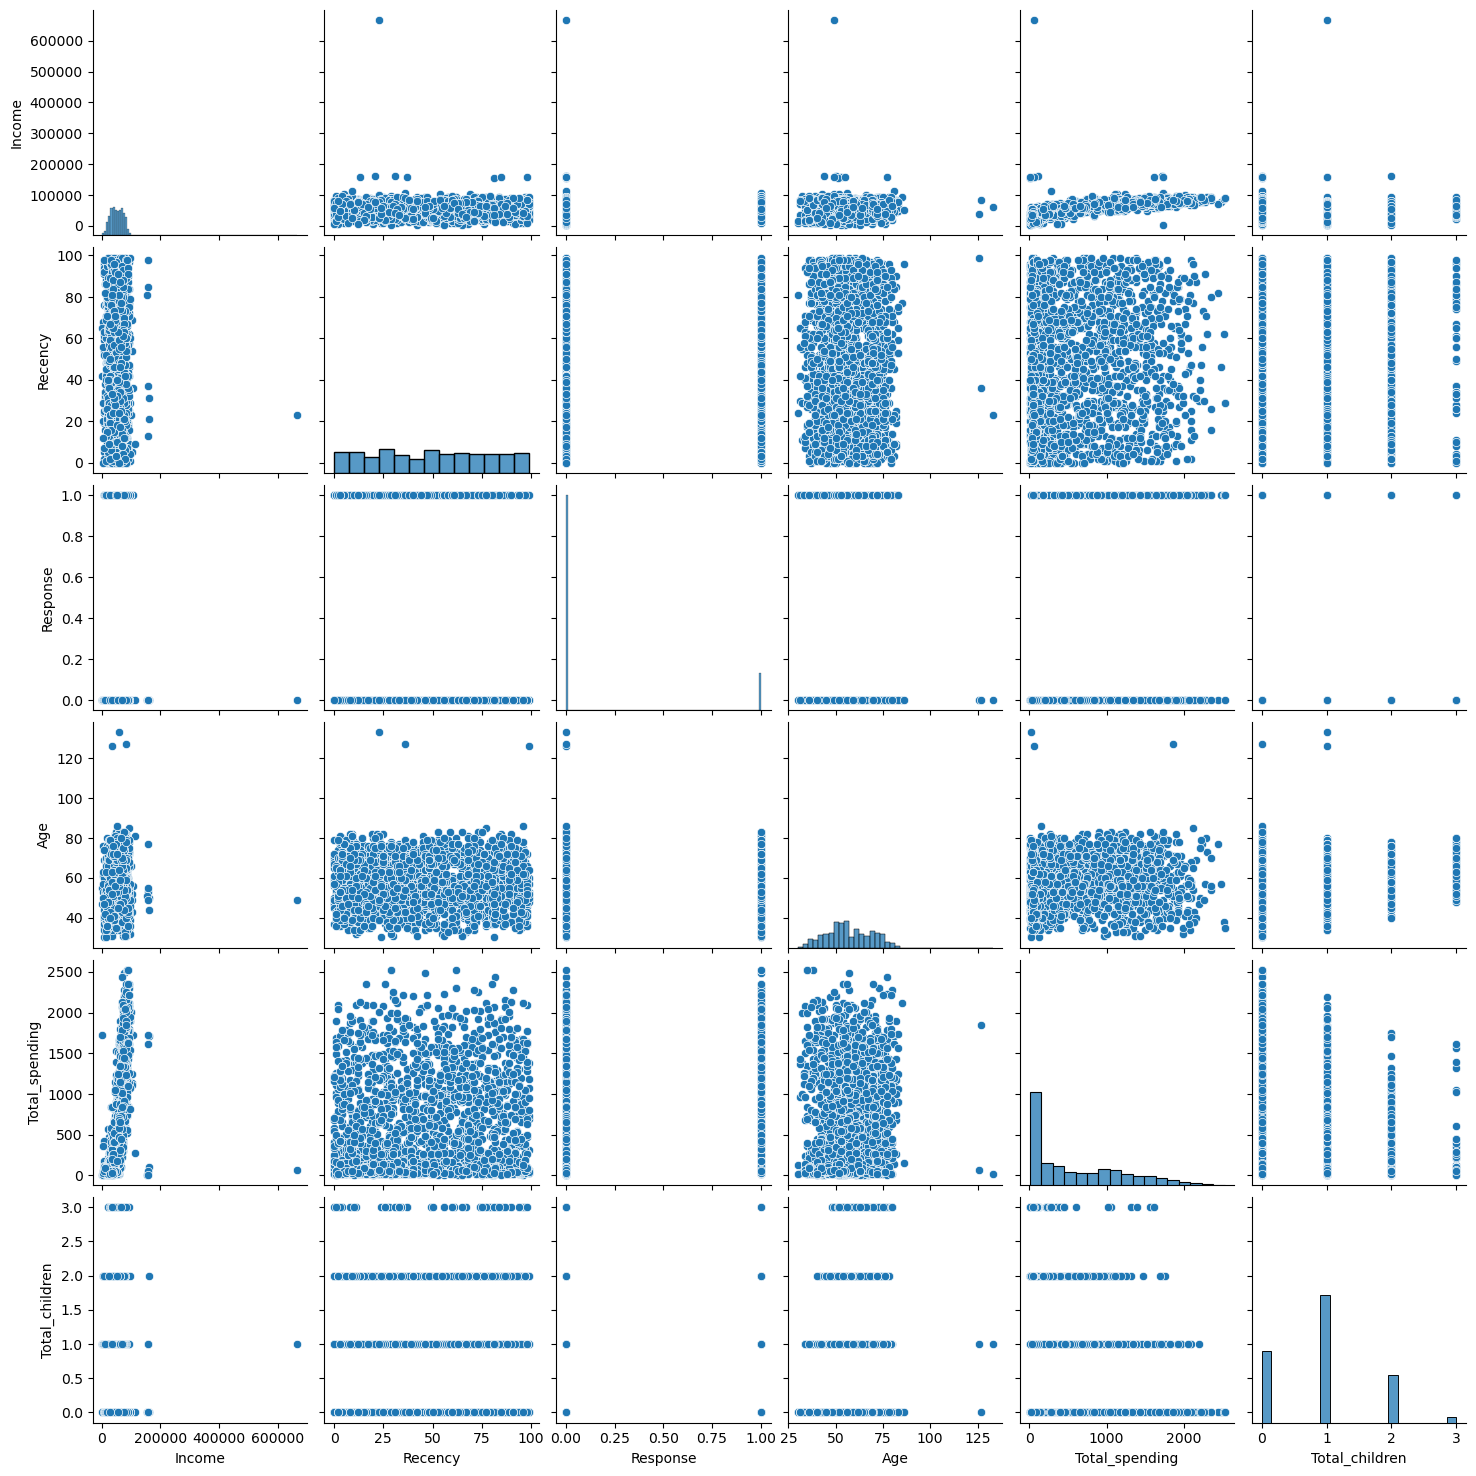

In [18]:
columns = ["Income", "Recency", "Response",  "Age", "Total_spending", "Total_children"]

# realtive  plots of some features - pair plots

sns.pairplot(df_cleaned[columns])

In [19]:
# Remove outliers

print("data size with outliers: ", len(df_cleaned))
df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600000 ) ]

print("data size without outliers : ", len(df_cleaned))

data size with outliers:  2240
data size without outliers :  2212


### Heatmap

In [20]:
corr_matrix = df_cleaned.corr(numeric_only = True)

<Axes: >

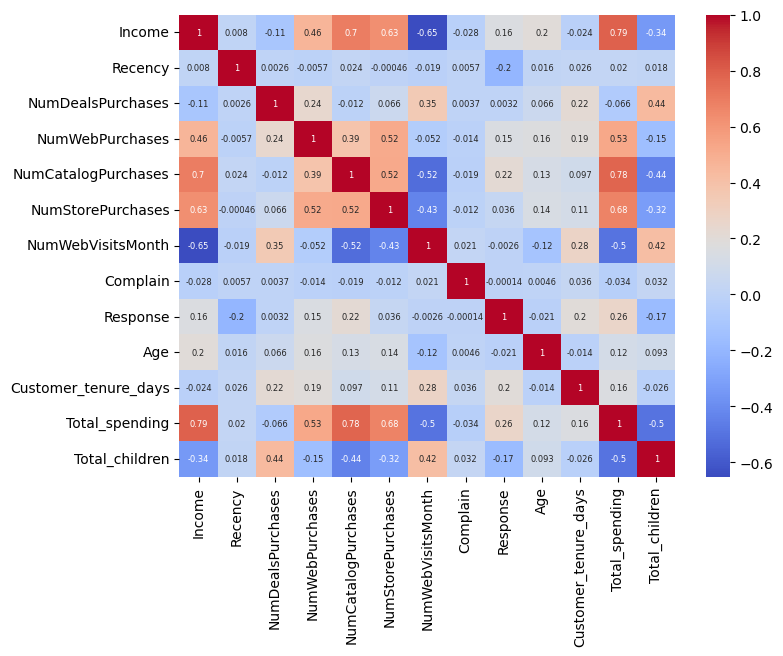

In [21]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    annot_kws = {"size": 6},
    cmap="coolwarm"
)

In [22]:
df_cleaned.shape

(2212, 15)

### Encoding

In [23]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [24]:
enc_df= pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [25]:
enc_df.head()

,Education_Postgraduate,Education_Undergraduate,Education_graduate,Living_With_Alone,Living_With_Partner
0,0.0,0.0,1.0,1.0,0.0
1,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0
3,0.0,0.0,1.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0


In [26]:
df_encoded = pd.concat([ df_cleaned.drop(columns = cat_cols), enc_df], axis = 1)

In [27]:
df_encoded.shape

(2212, 18)

In [28]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Total_children,Education_Postgraduate,Education_Undergraduate,Education_graduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0.0,0.0,1.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,0.0,0.0,1.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,0.0,1.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,0.0,1.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,1.0,0.0,0.0,0.0,1.0


In [29]:
X = df_encoded

### Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Visualize

In [31]:
X_scaled

array([[ 0.28710487,  0.31035323,  0.35102992, ...,  0.99189541,
         1.34960312, -1.34960312],
       [-0.26088203, -0.38081349, -0.16870113, ...,  0.99189541,
         1.34960312, -1.34960312],
       [ 0.9131964 , -0.79551352, -0.68843217, ...,  0.99189541,
        -0.74095857,  0.74095857],
       ...,
       [ 0.23334696,  1.45077832, -0.68843217, ...,  0.99189541,
         1.34960312, -1.34960312],
       [ 0.80317156, -1.41756357, -0.16870113, ..., -1.00817081,
        -0.74095857,  0.74095857],
       [ 0.04229031, -0.31169682,  0.35102992, ..., -1.00817081,
        -0.74095857,  0.74095857]], shape=(2212, 18))

In [32]:
# 2D 
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_scaled)

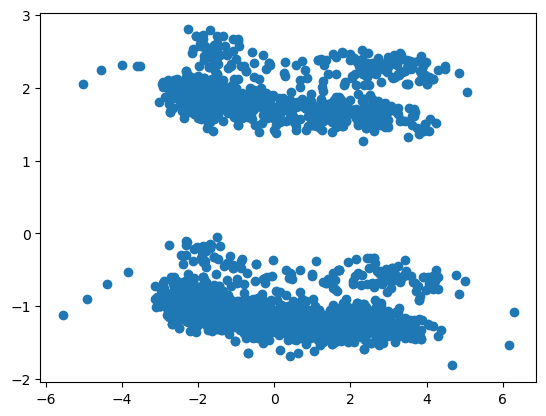

In [33]:
plt.scatter(x_pca[:, 0], x_pca[:, 1])

In [34]:
pca.explained_variance_ratio_

array([0.23258254, 0.11390916])

In [35]:
# 3D

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3d projection')

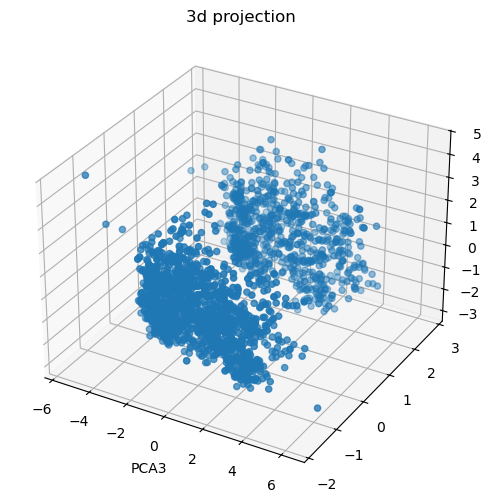

In [36]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_xlabel("PCA2")
ax.set_xlabel("PCA3")
ax.set_title("3d projection")

## Analyze K value
### 1. Elbow method

In [37]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [38]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [39]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [40]:
print("best k = ", optimal_k)

best k =  4


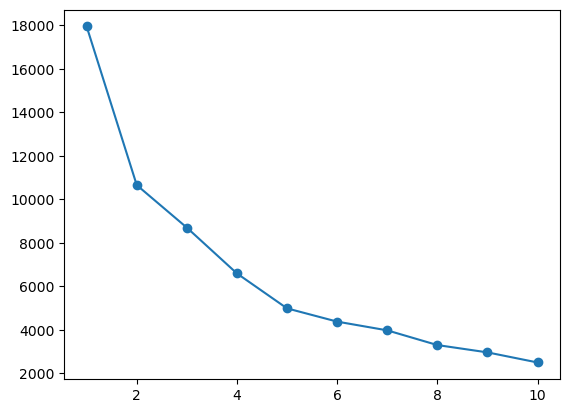

In [41]:
plt.plot(range(1, 11), wcss, marker="o")

### 2. Silhouette Score

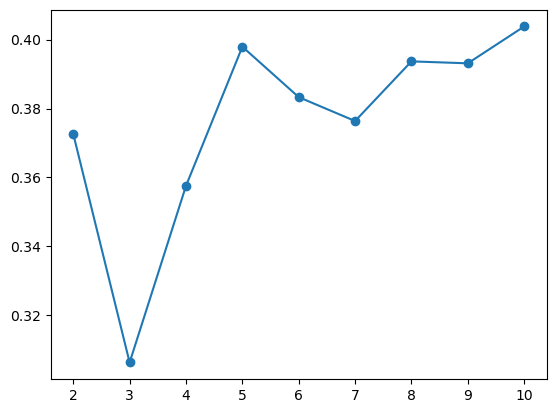

In [42]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)

    scores.append(score)



plt.plot(range(2, 11), scores, marker="o")

Text(0, 0.5, 'silhouette score')

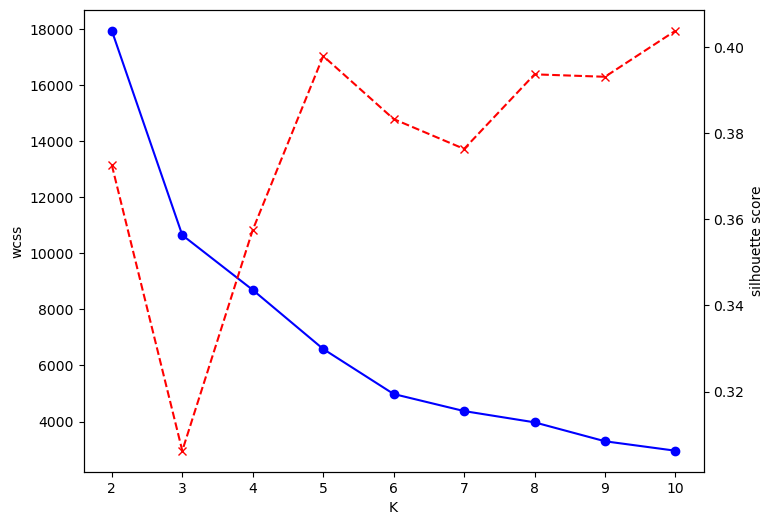

In [43]:
# Combined plot
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("silhouette score")

## Clustering

In [44]:
from sklearn.cluster import KMeans

In [45]:
k_means = KMeans(n_clusters=4, random_state=42)
labels_kmeans = k_means.fit_predict(X_pca)

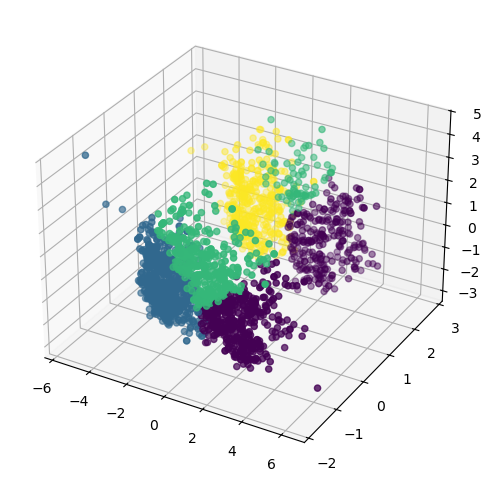

In [46]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [47]:
# agglomerative
from sklearn.cluster import AgglomerativeClustering

In [48]:
agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg.fit_predict(X_pca)

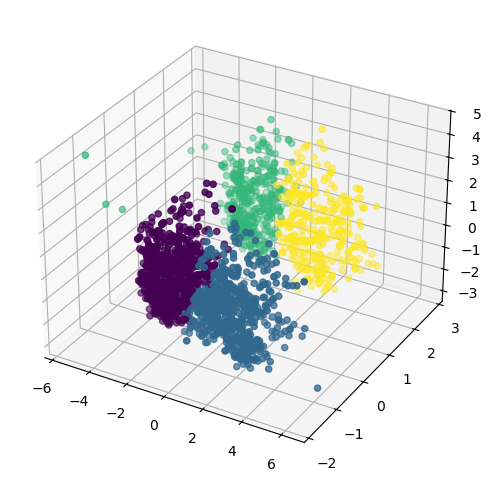

In [49]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

## Characterization of cluster

In [54]:
X["cluster"] = labels_agg

In [55]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Total_children,Education_Postgraduate,Education_Undergraduate,Education_graduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0.0,0.0,1.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,0.0,0.0,1.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,0.0,1.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,0.0,1.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,1.0,0.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

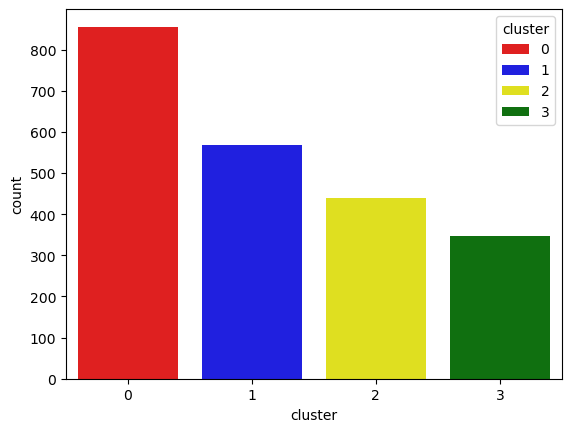

In [56]:

pal = ["red", "blue", "yellow", "green"]
sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

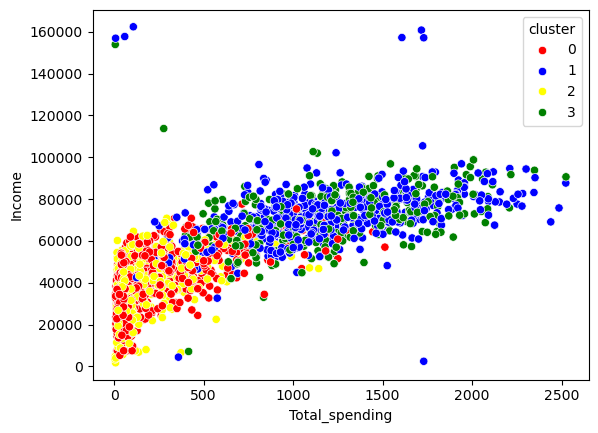

In [57]:
# Income & spending pattern

sns.scatterplot(x=X["Total_spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [59]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        38814.688084  49.113318           2.643692         3.063084   
1        71785.449912  48.810193           1.919156         5.662566   
2        36861.452273  48.034091           2.600000         2.736364   
3        71016.011527  50.380403           1.853026         5.749280   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.941589           4.070093           6.477804  0.009346   
1                   5.230228           8.469244           3.520211  0.008787   
2                   0.854545           3.643182           6.659091  0.011364   
3                   5.051873           8.466859           3.726225  0.005764   

         Response        Age  Customer_tenure_days  Total_spending  \
cluster         